In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import tqdm

from utils import plot_roc_curve, plot_pr_curve, find_best_roc_threshold, \
    find_best_f1_threshold, plot_confusion_matrix_at_threshold, calculate_accuracy_at_threshold, \
    clear_directory, mpl_figure_to_tensorboard_image, draw_rotated_rect_on_image, plot_image_with_label, \
    scores_swarmplot
from dataset import BarrettsHRMEDataset, create_dataloader

In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# if torch.cuda.is_available():
#     device = torch.device("cuda")
#     for i in range(torch.cuda.device_count()):
#         device_name = torch.cuda.get_device_name(i) 
#         print(f"Device {i} name: {device_name}")
# else:
#     print("CUDA not available!")

In [4]:
annotations_csv_filepath = "./HRME_image_annotations_dataset.csv"
df = pd.read_csv(annotations_csv_filepath)

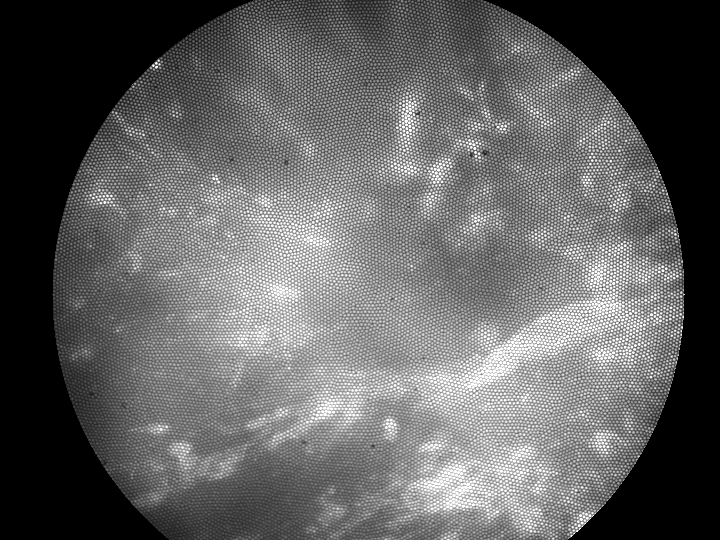

In [5]:
img_filepath = df.loc[0, "Lesion_HRME_Image_Filepath"]
mask_filepath = df.loc[0, "Lesion_HRME_Mask_Filepath"]
img = Image.open(img_filepath)
mask = Image.open(mask_filepath).convert("L")
black_image = Image.new("RGB", img.size, (0, 0, 0))
result = Image.composite(img, black_image, mask)
result

In [7]:
from Models.resnet import ResNet152_CBAM, ResNet152

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = ResNet152_CBAM(pretrained=True).to(device)
model = ResNet152().to(device)


/home/karthik/anaconda3/envs/barretts_algo_env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/karthik/anaconda3/envs/barretts_algo_env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
# model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet152', pretrained=True)
# num_ftrs = model.fc.in_features  # Get the input features of the last fully connected layer
# model.fc = nn.Sequential(
#     nn.Linear(num_ftrs, 512),  # Add a hidden layer for better generalization
#     nn.ReLU(),
#     nn.Dropout(0.5),  # Add dropout to prevent overfitting
#     nn.Linear(512, 1),  # Output layer with a single unit for binary classification
#     nn.Sigmoid()  # Sigmoid activation for binary classification (output between 0 and 1)
# )
# # # Freeze all parameters
# # for param in model.parameters():
# #     param.requires_grad = False

# # # Unfreeze parameters in the custom classifier (model.fc)
# # for param in model.fc.parameters():
# #     param.requires_grad = True
# model = model.to(device)

In [9]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [10]:
# Initialize dataset and dataloaders for the current fold
train_dataset = BarrettsHRMEDataset(annotations_csv_filepath, data_partition="train")
val_dataset = BarrettsHRMEDataset(annotations_csv_filepath, data_partition="test")

train_dataloader = create_dataloader(train_dataset)
val_dataloader = create_dataloader(val_dataset)

In [11]:
len(train_dataset), len(val_dataset)

(76, 27)

Make sure you close any running tensorboard process before running the following cell.

In [13]:
project_dir = Path("project_dir")
log_dir = project_dir / Path('tensorboard_logs/resnet')
# log_dir = project_dir / Path('tensorboard_logs/resnet_cbam')
clear_directory(log_dir)
writer = SummaryWriter(log_dir=log_dir)

Clearing directory: project_dir/tensorboard_logs/resnet


In [14]:
trained_models_dir = project_dir / Path("trained_models/resnet/models")
# trained_models_dir = project_dir / Path("trained_models/resnet_cbam/models")
clear_directory(trained_models_dir)
if not os.path.exists(trained_models_dir):
    os.makedirs(trained_models_dir)

trained_model_statedicts_dir = project_dir / Path("trained_models/resnet/model_state_dicts")
# trained_model_statedicts_dir = project_dir / Path("trained_models/resnet_cbam/model_state_dicts")
clear_directory(trained_model_statedicts_dir)
if not os.path.exists(trained_model_statedicts_dir):
    os.makedirs(trained_model_statedicts_dir)

Clearing directory: project_dir/trained_models/resnet/models
Clearing directory: project_dir/trained_models/resnet/model_state_dicts


In [15]:
num_epochs = 10  # Adjust based on your dataset size
best_accuracy = 0.0

for epoch in range(1, num_epochs+1):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    gt_train = []
    pred_train = []
    samples_train = []

    # Iterate through the training data
    for inputs, labels, samples in tqdm.tqdm(train_dataloader, desc=f'Epoch {epoch}/{num_epochs}', unit='batch'):

        gt_train += labels.numpy().tolist()
        samples_train += samples
        inputs, labels = inputs.to(device), labels.to(device).float()

        # Forward pass
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(1), labels)  # Squeeze to remove extra dimension for binary classification

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # Calculate accuracy
        predicted = (outputs.squeeze() > 0.5).float()  # Threshold at 0.5 for binary classification
        correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)

        pred_train += outputs.detach().squeeze(1).cpu().numpy().tolist()

    ############################ TRAINING METRICS ####################################
    # Get optimal thresholds and F1 Score
    train_best_roc_thresh, _, _ = find_best_roc_threshold(gt_train, pred_train)
    train_best_f1_thresh, train_best_f1 = find_best_f1_threshold(gt_train, pred_train)
    writer.add_scalar("Train Best ROC Threshold", train_best_roc_thresh, epoch)
    writer.add_scalar("Train Best PR Threshold", train_best_f1_thresh, epoch)
    writer.add_scalar('Train F1 Score', train_best_f1, epoch)

    # Plot confusion matrix at threshold for ROC
    plot_confusion_matrix_at_threshold(gt_train, pred_train, train_best_roc_thresh, ["Non-neoplastic", "Neoplastic"], 
                                       f"Optimal ROC Confusion Matrix (Epoch {epoch})")
    train_roc_confusion_matrix_npy = mpl_figure_to_tensorboard_image()
    writer.add_image("Train ROC - Confusion Matrix", train_roc_confusion_matrix_npy, epoch)

    # Plot confusion matrix at threshold for PR 
    plot_confusion_matrix_at_threshold(gt_train, pred_train, train_best_f1_thresh, ["Non-neoplastic", "Neoplastic"], 
                                       f"Optimal F1 Confusion Matrix (Epoch {epoch})")
    train_pr_confusion_matrix_npy = mpl_figure_to_tensorboard_image()
    writer.add_image("Train PR - Confusion Matrix", train_pr_confusion_matrix_npy, epoch)

    # Calculate accuracies at optimal ROC and F1 thresholds
    train_acc_roc_thresh = calculate_accuracy_at_threshold(gt_train, pred_train, train_best_roc_thresh)
    writer.add_scalar('Train Accuracy at optimal ROC threshold', train_acc_roc_thresh, epoch)
    train_acc_f1_thresh = calculate_accuracy_at_threshold(gt_train, pred_train, train_best_f1_thresh)
    writer.add_scalar('Train Accuracy at optimal F1 threshold', train_acc_f1_thresh, epoch)

    # Calculate training loss
    train_loss = running_loss / len(train_dataloader)
    writer.add_scalar('Training loss', train_loss, epoch)

    # Plot score distribution for training set
    scores_swarmplot(gt_train, pred_train, "Training Set Classifier Score Distribution", 
                     {'Threshold for best F1': train_best_f1_thresh, 
                      "Threshold for Youden's index": train_best_roc_thresh})
    train_scores_plot = mpl_figure_to_tensorboard_image()
    writer.add_image("Training Scores Distribution", train_scores_plot, epoch)

    # Visualize some of the misclassified images based on best ROC threshold
    pred_train_labels = (np.array(pred_train) >= train_best_roc_thresh).astype(int)
    misclassified = pred_train_labels!=gt_train
    misclassified_samples_train = np.array(samples_train)[misclassified].tolist()
    misclassified_images_train = []
    for s, p, gt in zip(misclassified_samples_train, np.array(pred_train)[misclassified], np.array(gt_train)[misclassified]):
        img = cv2.imread(s["image_filepath"], cv2.IMREAD_UNCHANGED)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        draw_rotated_rect_on_image(img, s["rotated_rect_corners"])
        plot_image_with_label(img, f"Pred: {p.item():.3f}, True: {gt.item()}")
        fig_npy = mpl_figure_to_tensorboard_image()
        misclassified_images_train.append(torch.from_numpy(fig_npy) / 255.0)
    misclassified_images_train = torch.stack(misclassified_images_train)
    grid = vutils.make_grid(
        misclassified_images_train[:16],
        nrow=4,
        normalize=True,
        scale_each=True,
        pad_value=1,
    )
    writer.add_image(f"Misclassified training images at best ROC threshold", grid, epoch)

    # Visualize some of the misclassified images based on best F1 threshold
    pred_train_labels = (np.array(pred_train) >= train_best_f1_thresh).astype(int)
    misclassified = pred_train_labels!=gt_train
    misclassified_samples_train = np.array(samples_train)[misclassified].tolist()
    misclassified_images_train = []
    for s, p, gt in zip(misclassified_samples_train, np.array(pred_train)[misclassified], np.array(gt_train)[misclassified]):
        img = cv2.imread(s["image_filepath"], cv2.IMREAD_UNCHANGED)
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        draw_rotated_rect_on_image(img, s["rotated_rect_corners"])
        plot_image_with_label(img, f"Pred: {p.item():.3f}, True: {gt.item()}")
        fig_npy = mpl_figure_to_tensorboard_image()
        misclassified_images_train.append(torch.from_numpy(fig_npy) / 255.0)
    misclassified_images_train = torch.stack(misclassified_images_train)
    grid = vutils.make_grid(
        misclassified_images_train[:16],
        nrow=4,
        normalize=True,
        scale_each=True,
        pad_value=1,
    )
    writer.add_image(f"Misclassified training images at best f1 threshold", grid, epoch)


    pred_test = []
    gt_test = []
    samples_test = []
    model.eval()
    with torch.no_grad():
        for inputs, labels, samples in val_dataloader:
            inputs, labels = inputs.to(device), labels.to(device).float()
            outputs = model(inputs)
            pred_test += outputs.squeeze(1).cpu().numpy().tolist()
            gt_test += labels.cpu().numpy().tolist()
            samples_test += samples

    torch.save(model, trained_models_dir / Path(f"model_epoch{epoch}.pt"))
    torch.save(model.state_dict(), trained_model_statedicts_dir / Path(f"model_state_dict_epoch{epoch}.pt"))

    ############################ TEST METRICS ####################################
    # Get optimal thresholds and F1 Score
    test_best_roc_thresh, _, _ = find_best_roc_threshold(gt_test, pred_test)
    test_best_f1_thresh, test_best_f1 = find_best_f1_threshold(gt_test, pred_test)
    writer.add_scalar("Test Best ROC Threshold", test_best_roc_thresh, epoch)
    writer.add_scalar("Test Best PR Threshold", test_best_f1_thresh, epoch)
    writer.add_scalar('Test F1 Score', test_best_f1, epoch)

    # Plot confusion matrix at threshold for ROC
    plot_confusion_matrix_at_threshold(gt_test, pred_test, test_best_roc_thresh, ["Non-neoplastic", "Neoplastic"], 
                                       f"Optimal ROC Confusion Matrix (Epoch {epoch})")
    test_roc_confusion_matrix_npy = mpl_figure_to_tensorboard_image()
    writer.add_image("Test ROC - Confusion Matrix", test_roc_confusion_matrix_npy, epoch)

    # Plot confusion matrix at threshold for PR 
    plot_confusion_matrix_at_threshold(gt_test, pred_test, test_best_f1_thresh, ["Non-neoplastic", "Neoplastic"], 
                                       f"Optimal F1 Confusion Matrix (Epoch {epoch})")
    test_pr_confusion_matrix_npy = mpl_figure_to_tensorboard_image()
    writer.add_image("Test PR - Confusion Matrix", test_pr_confusion_matrix_npy, epoch)

    # Calculate accuracies at optimal ROC and F1 thresholds
    test_acc_roc_thresh = calculate_accuracy_at_threshold(gt_test, pred_test, test_best_roc_thresh)
    writer.add_scalar('Test Accuracy at optimal ROC threshold', test_acc_roc_thresh, epoch)
    test_acc_f1_thresh = calculate_accuracy_at_threshold(gt_test, pred_test, test_best_f1_thresh)
    writer.add_scalar('Test Accuracy at optimal F1 threshold', test_acc_f1_thresh, epoch)

    # Plot score distribution for test set
    scores_swarmplot(gt_test, pred_test, "Test Set Classifier Score Distribution", 
                     {'Threshold for best F1': test_best_f1_thresh, 
                      "Threshold for Youden's index": test_best_roc_thresh})
    test_scores_plot = mpl_figure_to_tensorboard_image()
    writer.add_image("Test Scores Distribution", test_scores_plot, epoch)
    

    # Visualize some of the misclassified images based on best ROC threshold
    pred_test_labels = (np.array(pred_test) >= test_best_roc_thresh).astype(int)
    misclassified = pred_test_labels!=gt_test
    if np.any(misclassified):
        misclassified_samples_test = np.array(samples_test)[misclassified].tolist()
        misclassified_images_test = []
        for s, p, gt in zip(misclassified_samples_test, np.array(pred_test)[misclassified], np.array(gt_test)[misclassified]):
            img = cv2.imread(s["image_filepath"], cv2.IMREAD_UNCHANGED)
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            draw_rotated_rect_on_image(img, s["rotated_rect_corners"])
            plot_image_with_label(img, f"Pred: {p.item():.3f}, True: {gt.item()}")
            fig_npy = mpl_figure_to_tensorboard_image()
            misclassified_images_test.append(torch.from_numpy(fig_npy) / 255.0)
        misclassified_images_test = torch.stack(misclassified_images_test)
        grid = vutils.make_grid(
            misclassified_images_test[:16],
            nrow=4,
            normalize=True,
            scale_each=True,
            pad_value=1,
        )
        writer.add_image(f"Misclassified test images at best ROC threshold", grid, epoch)

    # Visualize some of the misclassified images based on best F1 threshold
    pred_test_labels = (np.array(pred_test) >= test_best_f1_thresh).astype(int)
    misclassified = pred_test_labels!=gt_test
    if np.any(misclassified):
        misclassified_samples_test = np.array(samples_test)[misclassified].tolist()
        misclassified_images_test = []
        for s, p, gt in zip(misclassified_samples_test, np.array(pred_test)[misclassified], np.array(gt_test)[misclassified]):
            img = cv2.imread(s["image_filepath"], cv2.IMREAD_UNCHANGED)
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            draw_rotated_rect_on_image(img, s["rotated_rect_corners"])
            plot_image_with_label(img, f"Pred: {p.item():.3f}, True: {gt.item()}")
            fig_npy = mpl_figure_to_tensorboard_image()
            misclassified_images_test.append(torch.from_numpy(fig_npy) / 255.0)
        misclassified_images_test = torch.stack(misclassified_images_test)
        grid = vutils.make_grid(
            misclassified_images_test[:16],
            nrow=4,
            normalize=True,
            scale_each=True,
            pad_value=1,
        )
        writer.add_image("Misclassified test images at best f1 threshold", grid, epoch)
        

    ############################# TRAINING/TEST ROC and PR Curves ################
    plot_roc_curve(gt_train, pred_train, color='blue', label=f"Training Epoch {epoch}", create_figure=True)
    plot_roc_curve(gt_test, pred_test, color='red', label=f"Test Epoch {epoch}", create_figure=False)
    roc_curve_npy = mpl_figure_to_tensorboard_image()
    writer.add_image("ROC Curve", roc_curve_npy, epoch)

    plot_pr_curve(gt_train, pred_train, color='blue', label=f"Training Epoch {epoch}", create_figure=True)
    plot_pr_curve(gt_test, pred_test, color='red', label=f"Test Epoch {epoch}", create_figure=False)
    pr_curve_npy = mpl_figure_to_tensorboard_image()
    writer.add_image("PR Curve", pr_curve_npy, epoch)

Epoch 10/10: 100%|██████████| 19/19 [00:31<00:00,  1.63s/batch]
